In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from numba import jit
import scipy
import pandas as pd
import seaborn as sns
import os

In [3]:
planets = pd.read_csv("../input/planets_triple.csv")

In [4]:
triples = pd.read_csv('../input/final_triple_5.csv')

In [5]:
from integrator import run_system
from integrator.experiments import generate_habitability_experiments
from integrator.batch import recommended_dt

In [6]:
configs = generate_habitability_experiments(
    triples,
    planets,
    tf=1e5,
    output_dir='../output',
)

# Compute dt and output cadence for each config
for cfg in configs:
    cfg["dt"] = recommended_dt(cfg)
    cfg["output_every_n"] = max(1, int(1.0 / cfg["dt"]))  # ~1 snapshot per year

print(f"Generated {len(configs)} experiment configs")
print(f"tf = {configs[0]['tf']:.0f} yr")
print(f"Example dt = {configs[0]['dt']:.6g} yr")
print(f"Example output_every_n = {configs[0]['output_every_n']}")
print(f"Example snapshots = {int(configs[0]['tf'] / configs[0]['dt'] / configs[0]['output_every_n'])}")

Generated 106 experiment configs
tf = 100000 yr
Example dt = 0.00203401 yr
Example output_every_n = 491
Example snapshots = 100130


In [ ]:
# --- Post-processing: compute orbital elements, energy, temperature, HZ ---
from integrator import postprocess

for i, cfg in enumerate(configs):
    path = cfg['output_file']
    if os.path.exists(path):
        print(f"[{i+1}/{len(configs)}] Post-processing: {cfg['experiment_name']}")
        try:
            postprocess(path)
        except Exception as exc:
            print(f"  FAIL: {exc}")
    else:
        print(f"[{i+1}/{len(configs)}] Missing: {cfg['experiment_name']}")

print("Post-processing complete.")

[1/106] Post-processing: Gliese_667_observed_ev0.0_iv000
[2/106] Post-processing: Gliese_667_observed_ev0.0_iv030
[3/106] Post-processing: Gliese_667_observed_ev0.0_iv060
[4/106] Post-processing: Gliese_667_observed_ev0.0_iv090
[5/106] Post-processing: Gliese_667_observed_ev0.2_iv000
[6/106] Post-processing: Gliese_667_observed_ev0.2_iv030
[7/106] Post-processing: Gliese_667_observed_ev0.2_iv060
[8/106] Post-processing: Gliese_667_observed_ev0.2_iv090
[9/106] Post-processing: Gliese_667_observed_ev0.4_iv000
[10/106] Post-processing: Gliese_667_observed_ev0.4_iv030
[11/106] Post-processing: Gliese_667_observed_ev0.4_iv060
[12/106] Post-processing: Gliese_667_observed_ev0.4_iv090
[13/106] Post-processing: Gliese_667_observed_ev0.6_iv000
[14/106] Post-processing: Gliese_667_observed_ev0.6_iv030
[15/106] Post-processing: Gliese_667_observed_ev0.6_iv060
[16/106] Post-processing: Gliese_667_observed_ev0.6_iv090
[17/106] Post-processing: Gliese_667_observed_ev0.8_iv000
[18/106] Post-processin

In [9]:
def load_hdf5_data(H5_PATH):
    with h5py.File(H5_PATH, "r") as f:
        keys = sorted(
            [k for k in f.keys() if k.startswith("Step_")],
            key=lambda s: int(s.split("_")[1])
        )
        t_list, pos_list, mass_list, ptype_list, energy_list, temperature_list, in_hz_list = [], [], [], [], [], [], []
        hz_inner_radius_list, hz_outer_radius_list = [], []
        a_list, e_list, inc_list = [], [], []
        for k in keys:
            g = f[k]
            t_list.append(g["time"][:])
            pos_list.append(g["pos"][:])
            mass_list.append(g["mass"][:])
            ptype_list.append(g["ptype"][:])
            
            hz_inner_radius_list.append(g["hz_inner_radius"][:])
            hz_outer_radius_list.append(g["hz_outer_radius"][:])
            energy_list.append(g["energy"][:])
            temperature_list.append(g["temperature"][:])
            in_hz_list.append(g["in_hz"][:])
            a_list.append(g["a"][:])
            e_list.append(g["e"][:])
            inc_list.append(g["inc"][:])
            
    t = np.concatenate(t_list)
    pos = np.concatenate(pos_list)
    mass = np.concatenate(mass_list)
    ptype = np.concatenate(ptype_list)
    hz_inner_radius = np.concatenate(hz_inner_radius_list)
    hz_outer_radius = np.concatenate(hz_outer_radius_list)
    energy = np.concatenate(energy_list)
    temperature = np.concatenate(temperature_list)
    in_hz = np.concatenate(in_hz_list)
    a = np.concatenate(a_list)
    e = np.concatenate(e_list)
    inc = np.concatenate(inc_list)

    n_particles = mass.shape[1]
    if pos.ndim == 2:
        pos = pos.reshape(pos.shape[0], n_particles, 3)

    return t, pos, mass, ptype, hz_inner_radius, hz_outer_radius, energy, temperature, in_hz, a, e, inc

def determine_system(mass, pos, ptype):
    star_idx = np.where(ptype[0] == 0)[0]
    planet_idx = np.where(ptype[0] == 1)[0]
    m0 = mass[0]

    iA, iB = star_idx[0], star_idx[1]
    iC = star_idx[2] if len(star_idx) > 2 else None
    mA, mB = m0[iA], m0[iB]
    r_com_bin = (mA * pos[:, iA, :] + mB * pos[:, iB, :]) / (mA + mB)

    return star_idx, planet_idx, iA, iB, iC, mA, mB, r_com_bin

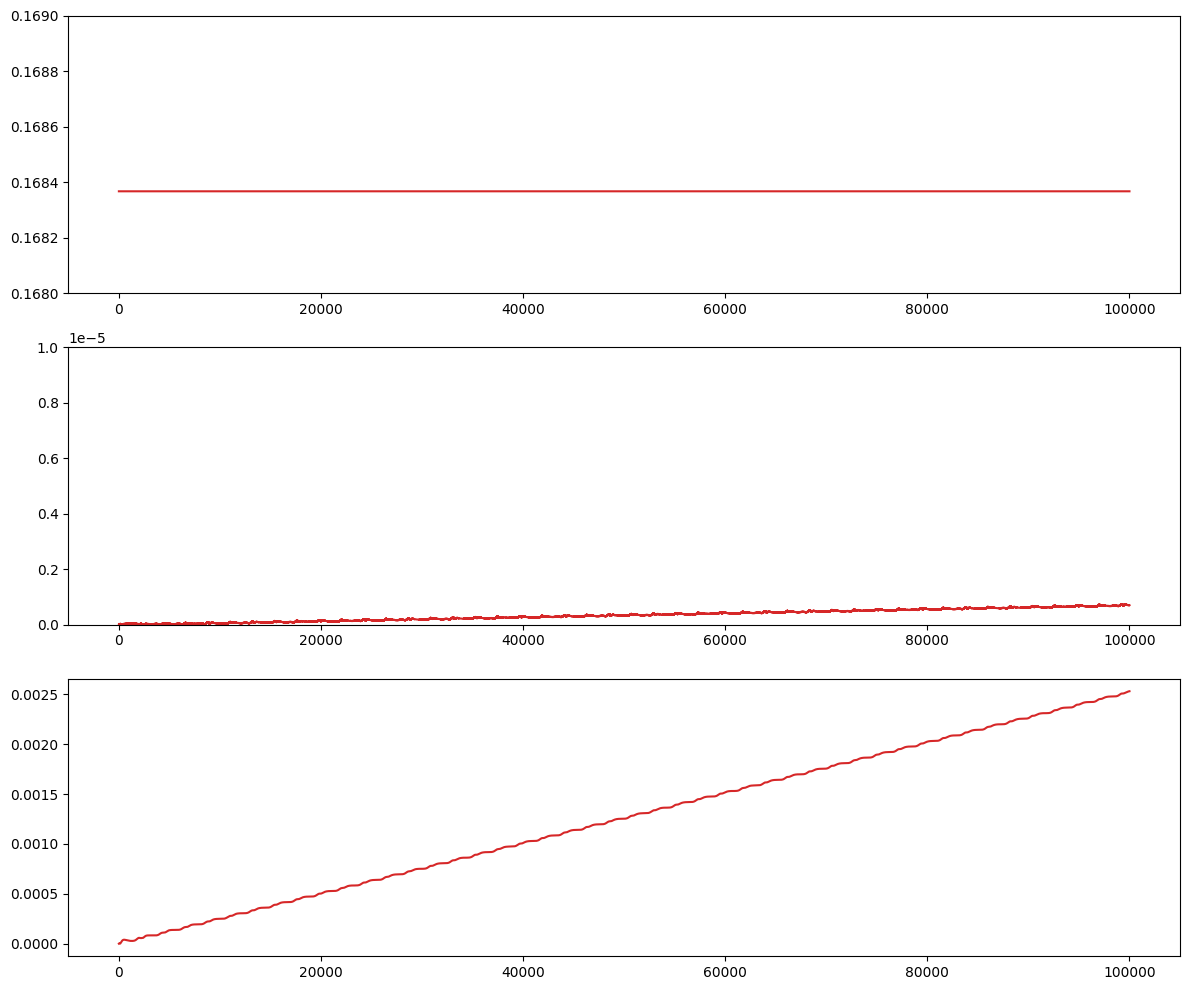

In [29]:
path = '../output/94_Ceti_hz_inner_ev0.3_iv104.hdf5'
t, pos, mass, ptype, hz_inner_radius, hz_outer_radius, energy, temperature, in_hz, a, e, inc = load_hdf5_data(path)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

ax = axes[0]
ax.set_ylim([0.168, 0.169])
ax.plot(t, a)

ax=axes[1]
ax.set_ylim([0.0, 0.00001])
ax.plot(t, e)

ax=axes[2]
ax.plot(t, inc)

plt.tight_layout()
plt.show()

E0 = -14.39957273107191
max |ΔE/E0| = 2.3434359229727745e-08


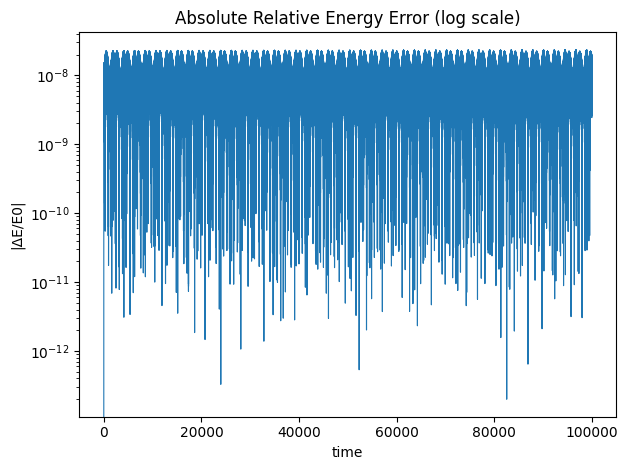

[-14.39957273 -14.39957251 -14.39957272 -14.3995726  -14.39957258
 -14.39957273 -14.39957251 -14.39957272 -14.3995726  -14.39957259]


In [30]:
mask = np.isfinite(energy) & np.isfinite(t)
t = t[mask]
energy = energy[mask]

E0 = energy[0]
dE = energy - E0
rel = dE / abs(E0)

print("E0 =", E0)
print("max |ΔE/E0| =", np.max(np.abs(rel)))

plt.figure()

# Absolute relative error (paper-style)
plt.semilogy(t, np.abs(dE/E0), lw=0.8)
plt.xlabel("time")
plt.ylabel("|ΔE/E0|")
plt.title("Absolute Relative Energy Error (log scale)")

plt.tight_layout()
plt.show()


print(energy[:10])